In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("data/medical-charges.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
print(df.duplicated().sum())

1


In [7]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    
    print("Data type:", df[col].dtype)
    print("Unique values:", df[col].nunique())
    print("Missing values:", df[col].isnull().sum())
    
    if df[col].dtype == "object":
        print("\nValue distribution:")
        print(df[col].value_counts(normalize=True))
    else:
        print("\nDescriptive statistics:")
        print(df[col].describe())


Column: age
Data type: int64
Unique values: 47
Missing values: 0

Descriptive statistics:
count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Column: sex
Data type: object
Unique values: 2
Missing values: 0

Value distribution:
sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64

Column: bmi
Data type: float64
Unique values: 548
Missing values: 0

Descriptive statistics:
count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

Column: children
Data type: int64
Unique values: 6
Missing values: 0

Descriptive statistics:
count    1338.000000
mean        1.094918
std         1.205493
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Na

In [8]:
for col in ["sex", "smoker", "region","charges"]:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"Total unique values: {df[col].nunique()}")
    print("\nCount:")
    print(df[col].value_counts())


Column: sex
Total unique values: 2

Count:
sex
male      676
female    662
Name: count, dtype: int64

Column: smoker
Total unique values: 2

Count:
smoker
no     1064
yes     274
Name: count, dtype: int64

Column: region
Total unique values: 4

Count:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Column: charges
Total unique values: 1337

Count:
charges
1639.56310     2
6203.90175     1
12981.34570    1
28101.33305    1
28923.13692    1
              ..
1163.46270     1
19496.71917    1
7201.70085     1
5425.02335     1
16115.30450    1
Name: count, Length: 1337, dtype: int64


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
bins = [17, 22, 27, 32, 37, 42, 47, 52, 57, 62, 67]

labels = [
    "18-22",
    "23-27",
    "28-32",
    "33-37",
    "38-42",
    "43-47",
    "48-52",
    "53-57",
    "58-62",
    "63-67"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

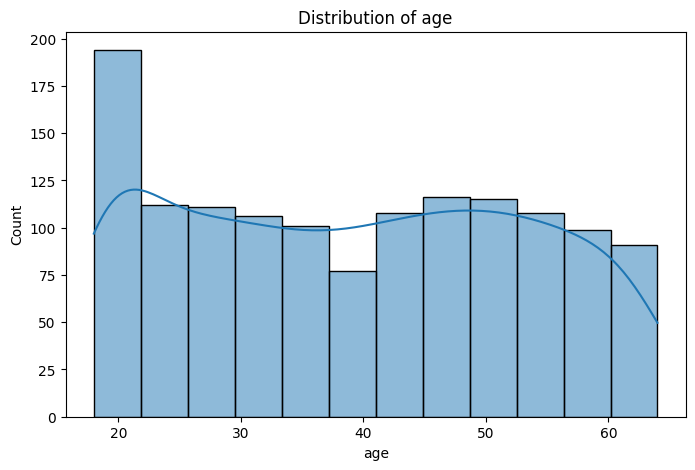

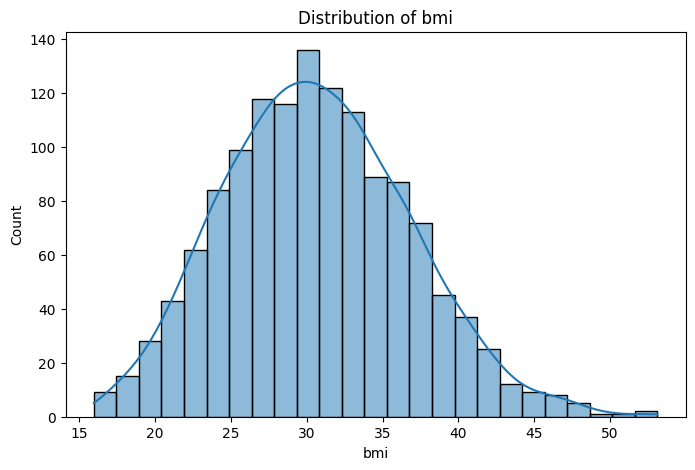

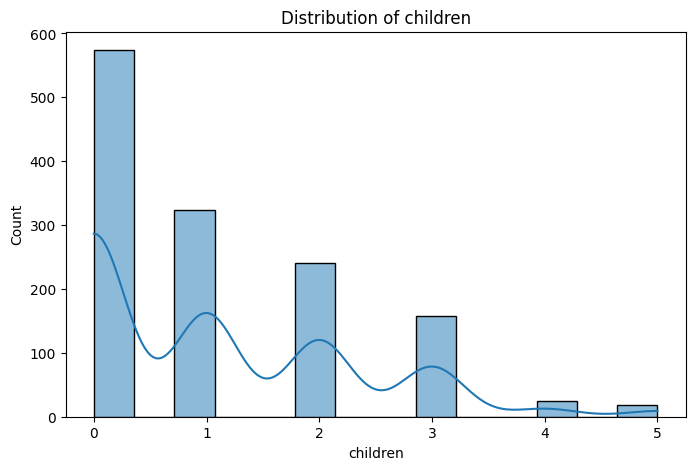

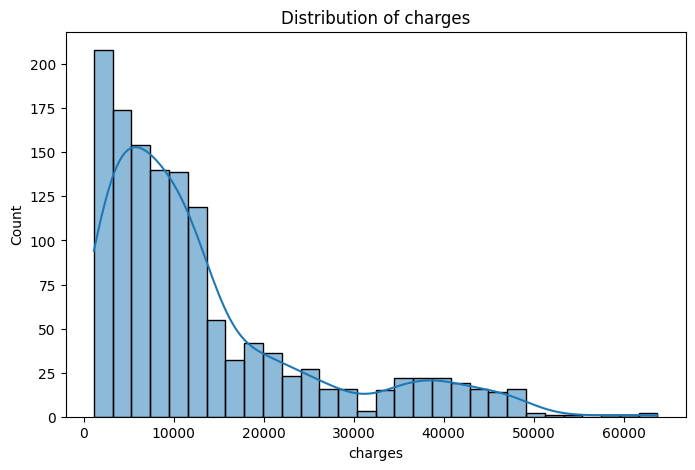

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["age", "bmi", "children", "charges"]

for col in num_cols:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(data=df, x=col, kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

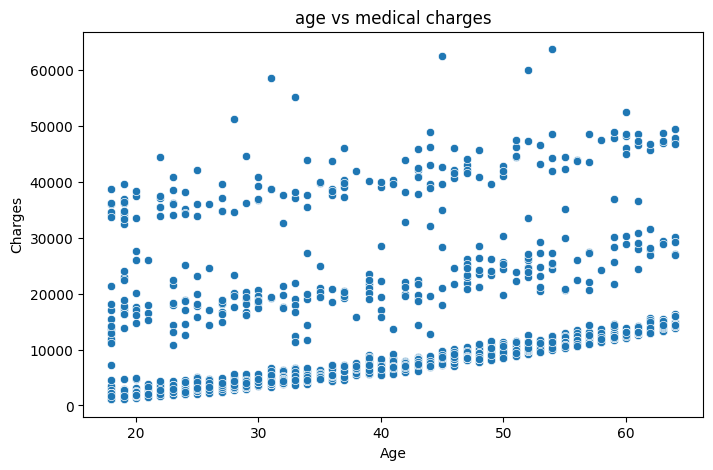

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data = df,
    x = "age",
    y = "charges"
)
plt.title("age vs medical charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

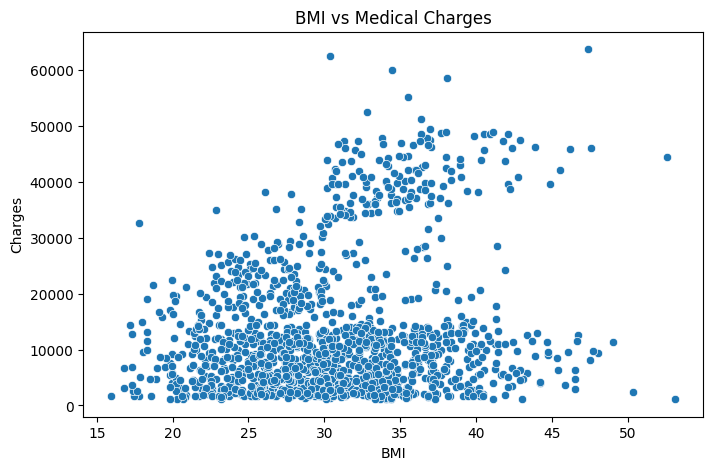

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

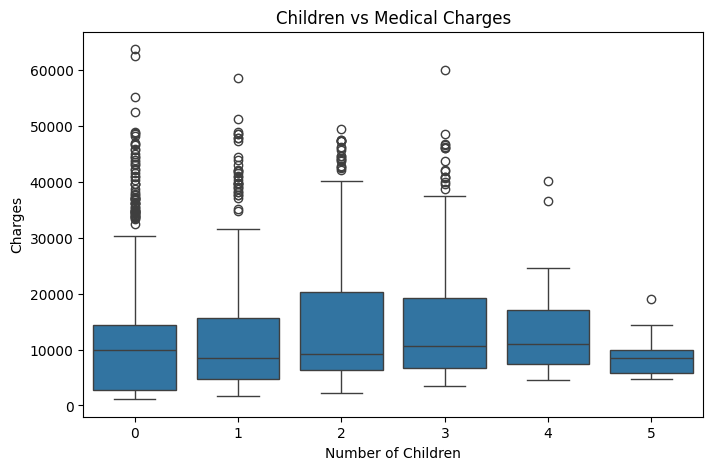

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="children",
    y="charges"
)

plt.title("Children vs Medical Charges")
plt.xlabel("Number of Children")
plt.ylabel("Charges")
plt.show()

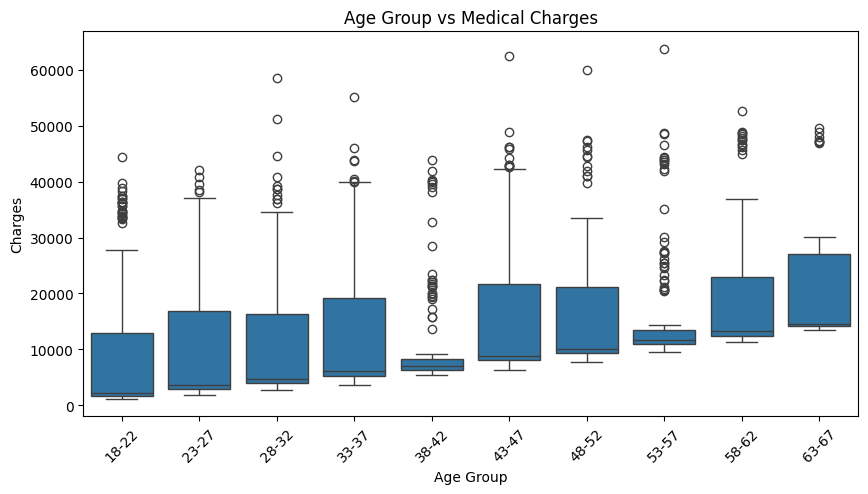

In [15]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="age_group",
    y="charges"
)

plt.title("Age Group vs Medical Charges")
plt.xlabel("Age Group")
plt.ylabel("Charges")
plt.xticks(rotation=45)
plt.show()

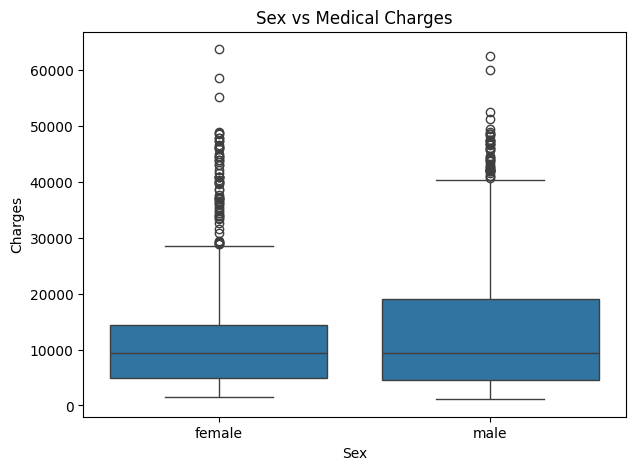

In [16]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="sex",
    y="charges"
)

plt.title("Sex vs Medical Charges")
plt.xlabel("Sex")
plt.ylabel("Charges")
plt.show()

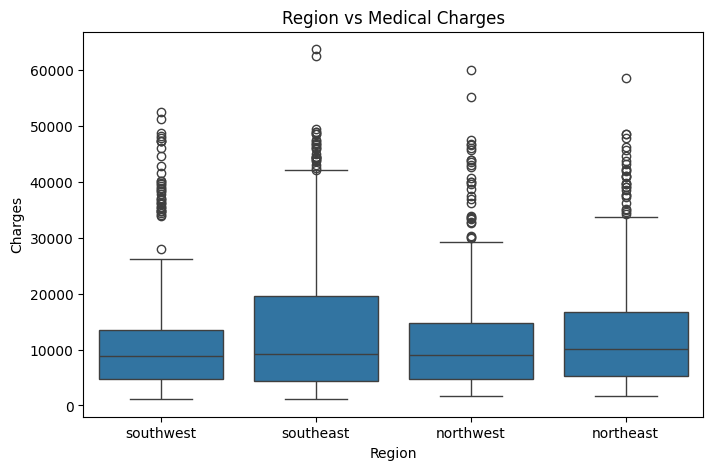

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Region vs Medical Charges")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

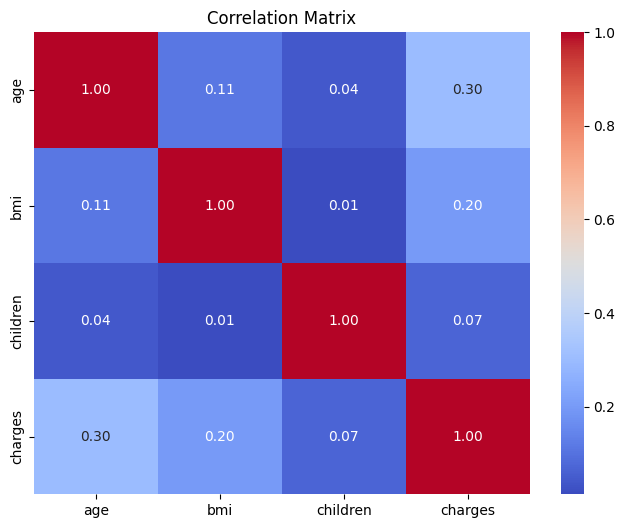

In [18]:
corr_cols = ["age", "bmi", "children", "charges"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

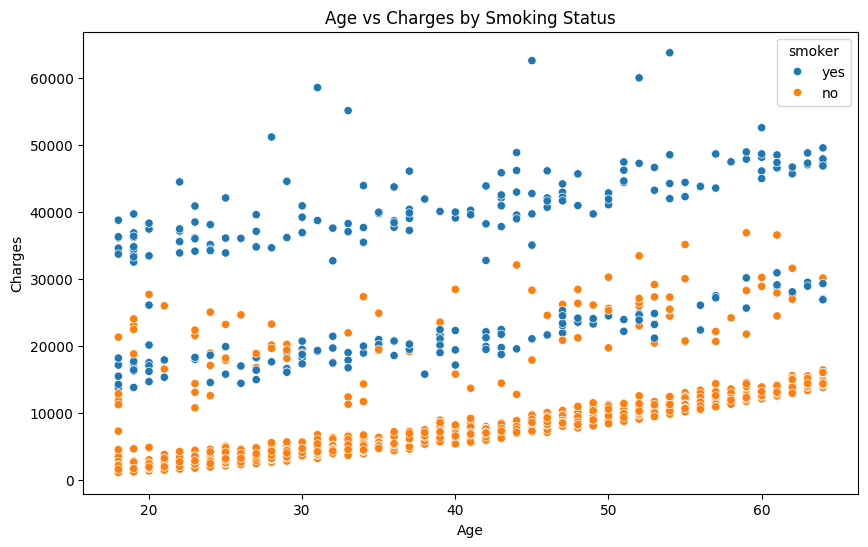

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

In [20]:
corr = df[["age", "bmi", "children", "charges"]].corr()["charges"]

corr = corr.drop("charges").sort_values(ascending=False)

print(corr)

age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


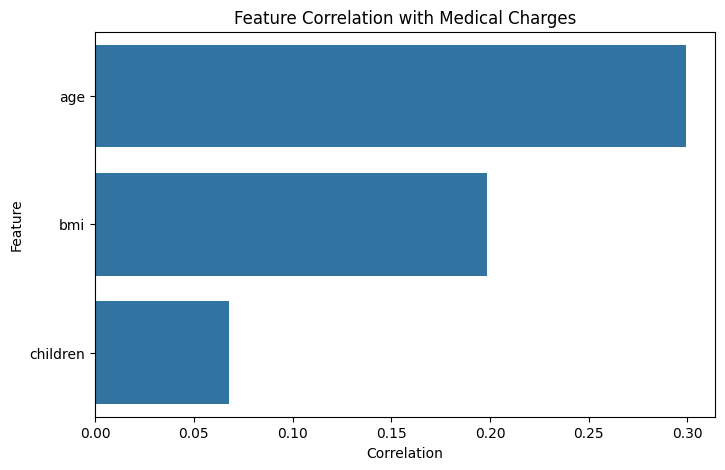

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=corr.values,
    y=corr.index
)

plt.title("Feature Correlation with Medical Charges")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,18-22
1,18,male,33.770,1,no,southeast,1725.55230,18-22
2,28,male,33.000,3,no,southeast,4449.46200,28-32
3,33,male,22.705,0,no,northwest,21984.47061,33-37
4,32,male,28.880,0,no,northwest,3866.85520,28-32


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- 1. Encoding ----

# One-hot encode 'region' (creates separate columns per region, drops first to avoid dummy trap)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Binary categorical columns -> label encode (or map manually, cleaner/more readable)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# If you created 'age_group' during EDA and don't need it for modeling, drop it
# (keep it only if you want to one-hot encode it too — otherwise it's redundant with 'age')
if 'age_group' in df.columns:
    df = df.drop(columns=['age_group'])

print(df.head())
print(df.dtypes)

# ---- 2. Separate X and y ----

X = df.drop(columns=['charges'])
y = df['charges']

# ---- 3. Train-test split ----

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- 4. Linear Regression ----

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("\n--- Linear Regression ---")
print("MAE :", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2  :", r2_score(y_test, lr_preds))

# ---- 5. Random Forest ----

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\n--- Random Forest ---")
print("MAE :", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2  :", r2_score(y_test, rf_preds))

# ---- 6. Feature importance (Random Forest) ----

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances (RF):\n", importances)

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    1  27.900         0       1  16884.92400             False   
1   18    0  33.770         1       0   1725.55230             False   
2   28    0  33.000         3       0   4449.46200             False   
3   33    0  22.705         0       0  21984.47061              True   
4   32    0  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

--- Linear Regression ---
MAE : 4181.194473753647
RMSE: 5796

In [24]:
print("\n--- Linear Regression ---")
print("MAE :", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2  :", r2_score(y_test, lr_preds))


--- Linear Regression ---
MAE : 4181.194473753647
RMSE: 5796.284659276272
R2  : 0.7835929767120724


In [25]:

print("\n--- Random Forest ---")
print("MAE :", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2  :", r2_score(y_test, rf_preds))


--- Random Forest ---
MAE : 2547.2853909363057
RMSE: 4568.162548455776
R2  : 0.865582740235016


In [26]:
from sklearn.model_selection import GridSearchCV

# ---- Hyperparameter grid ----
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                          # 5-fold cross-validation
    scoring='r2',                  # optimize for R²
    n_jobs=-1,                     # use all CPU cores
    verbose=2                      # print progress
)

grid_search.fit(X_train, y_train)

# ---- Best params & score ----
print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)

# ---- Evaluate best model on test set ----
best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)

print("\n--- Tuned Random Forest (Test Set) ---")
print("MAE :", mean_absolute_error(y_test, best_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_preds)))
print("R2  :", r2_score(y_test, best_preds))

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV R² Score: 0.8459706186606555

--- Tuned Random Forest (Test Set) ---
MAE : 2502.0954966153845
RMSE: 4350.955864642758
R2  : 0.8780613744526966


In [28]:
# If not installed, uncomment:
# !pip install xgboost

from xgboost import XGBRegressor

# ---- XGBoost with default params first (baseline) ----
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("--- XGBoost (default) ---")
print("MAE :", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("R2  :", r2_score(y_test, xgb_preds))

# ---- XGBoost hyperparameter tuning ----
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

xgb_grid_search.fit(X_train, y_train)

print("\nBest Parameters:", xgb_grid_search.best_params_)
print("Best CV R² Score:", xgb_grid_search.best_score_)

best_xgb = xgb_grid_search.best_estimator_
best_xgb_preds = best_xgb.predict(X_test)

print("\n--- Tuned XGBoost (Test Set) ---")
print("MAE :", mean_absolute_error(y_test, best_xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_xgb_preds)))
print("R2  :", r2_score(y_test, best_xgb_preds))

--- XGBoost (default) ---
MAE : 2802.4253602505396
RMSE: 4905.280422446859
R2  : 0.8450114484567273
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R² Score: 0.8490691181587096

--- Tuned XGBoost (Test Set) ---
MAE : 2536.2566102997316
RMSE: 4296.094314747948
R2  : 0.8811170552965991


In [29]:
import joblib

# Save model
joblib.dump(best_xgb, 'best_model_xgboost.pkl')

# Save the column order used during training (critical for correct predictions later)
joblib.dump(list(X_train.columns), 'model_columns.pkl')

# Optional: save a small metadata dict for reference
metadata = {
    'model_type': 'XGBoost (tuned)',
    'best_params': xgb_grid_search.best_params_,
    'test_r2': 0.8811,
    'test_mae': 2536.26,
    'test_rmse': 4296.09
}
joblib.dump(metadata, 'model_metadata.pkl')

['model_metadata.pkl']